## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Estilo dos gráficos exportados para o relatório (img/)
COR = "#2f5d50"
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e3da",
    "axes.titlelocation": "left",
})

## Load do Dataset

In [2]:
df = pd.read_csv("./dataset/DailyDelhiClimateTrain.csv")

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Documentação da Base

| Item | Descrição |
|---|---|
| **Fonte** | Kaggle — *Daily Climate time series data* (sumanthvrao), coletado da API do Weather Underground. Licença CC0. |
| **Descrição** | Clima diário da cidade de Delhi (Índia). |
| **Variável-alvo** | `meantemp` — temperatura média diária, calculada a partir de leituras a cada 3 horas |
| **Unidade** | °C |
| **Frequência** | Diária |
| **Período** | Treino: 01/01/2013 a 01/01/2017 (1.462 obs.) · Teste: 01/01/2017 a 24/04/2017 (114 obs.) |

### Dicionário das variáveis externas

| Variável | Descrição | Unidade | Tipo | Uso |
|---|---|---|---|---|
| `humidity` | Umidade relativa média diária do ar | % | contínua | mantida |
| `wind_speed` | Velocidade média diária do vento | km/h | contínua | mantida |
| `meanpressure` | Pressão atmosférica média diária | hPa | contínua | **excluída** (valores impossíveis, ver abaixo) |

## Qualidade dos Dados

In [3]:
raw = pd.read_csv("./dataset/DailyDelhiClimateTrain.csv", parse_dates=["date"])

print("Valores ausentes por coluna:")
print(raw.isna().sum().to_string())

print("\nLinhas duplicadas:", raw.duplicated().sum())
print("Datas duplicadas:", raw["date"].duplicated().sum())

# Irregularidades temporais: datas faltantes no calendário diário
calendario = pd.date_range(raw["date"].min(), raw["date"].max(), freq="D")
print("\nDias esperados:", len(calendario), "| dias presentes:", raw["date"].nunique())
print("Datas faltantes:", list(calendario.difference(raw["date"])))

# Zeros no vento podem indicar falha de registro
print("\nDias com wind_speed = 0:", (raw["wind_speed"] == 0).sum())

print("\nÚltimas linhas:")
print(raw.tail(2))

Valores ausentes por coluna:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0

Linhas duplicadas: 0
Datas duplicadas: 0

Dias esperados: 1462 | dias presentes: 1462
Datas faltantes: []

Dias com wind_speed = 0: 26

Últimas linhas:
           date   meantemp  humidity  wind_speed  meanpressure
1460 2016-12-31  15.052632      87.0       7.325        1016.1
1461 2017-01-01  10.000000     100.0       0.000        1016.0


In [4]:
# Outliers pela regra do IQR
def outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)]

for col in ["meantemp", "humidity", "wind_speed", "meanpressure"]:
    o = outliers_iqr(raw[col])
    faixa = f"(de {o.min():.1f} a {o.max():.1f})" if len(o) else ""
    print(f"{col}: {len(o)} outliers {faixa}")

# A pressão ao nível do mar fica entre ~990 e 1030 hPa
print("\nmeanpressure fora do IQR:", sorted(outliers_iqr(raw["meanpressure"]).round(0)))

meantemp: 0 outliers 
humidity: 2 outliers (de 13.4 a 15.9)
wind_speed: 30 outliers (de 17.9 a 42.2)
meanpressure: 9 outliers (de -3.0 a 7679.3)

meanpressure fora do IQR: [-3.0, 12.0, 310.0, 634.0, 938.0, 946.0, 1350.0, 1353.0, 7679.0]


**Interpretação:**
- Não há valores ausentes, linhas ou datas duplicadas, nem datas faltantes: a frequência diária é contínua.
- `wind_speed` tem 26 dias com valor exatamente 0, que podem ser falhas de registro. Foram mantidos porque vento calmo é plausível.
- `meantemp` não tem outliers. Em `humidity` há 2 (13–16%) e em `wind_speed` há 30 (18–42 km/h), todos fisicamente plausíveis e mantidos.
- `meanpressure` tem valores impossíveis (−3, 12, 310, 634, 1.350 e 7.679 hPa), sinal de erro de coleta. A coluna foi excluída.
- A última linha (01/01/2017) está incompleta (umidade 100, vento 0) e coincide com a primeira data do arquivo de teste.

**Decisões de limpeza e transformação:**
1. Exclusão de `meanpressure`.
2. Remoção da última linha, para não sobrepor treino e teste.
3. Sem transformação da alvo (log/Box-Cox): a série é aditiva e a amplitude do ciclo anual é estável entre os anos.

## Limpeza

In [5]:
df = df.drop(columns=["meanpressure"])
df["date"] = pd.to_datetime(df["date"]) 
df = df.set_index("date")

# Remove a última linha (2017-01-01): registro incompleto (umidade 100, vento 0)
# e a data já é o início do dataset de teste
df = df.iloc[:-1]

df.head()

,meantemp,humidity,wind_speed
date,,,
2013-01-01,10.000000,84.500000,0.000000
2013-01-02,7.400000,92.000000,2.980000
2013-01-03,7.166667,87.000000,4.633333
2013-01-04,8.666667,71.333333,1.233333
2013-01-05,6.000000,86.833333,3.700000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2013-01-01 to 2016-12-31
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   meantemp    1461 non-null   float64
 1   humidity    1461 non-null   float64
 2   wind_speed  1461 non-null   float64
dtypes: float64(3)
memory usage: 45.7 KB


## Representação Visual da Série

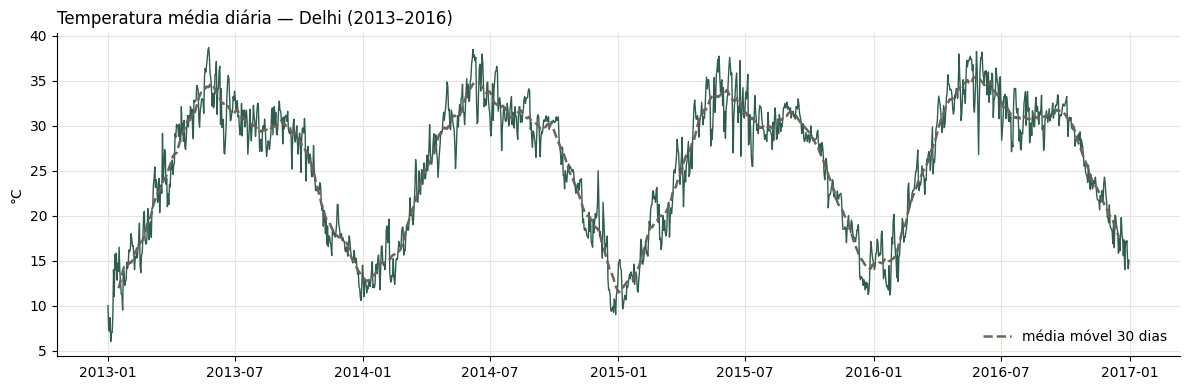

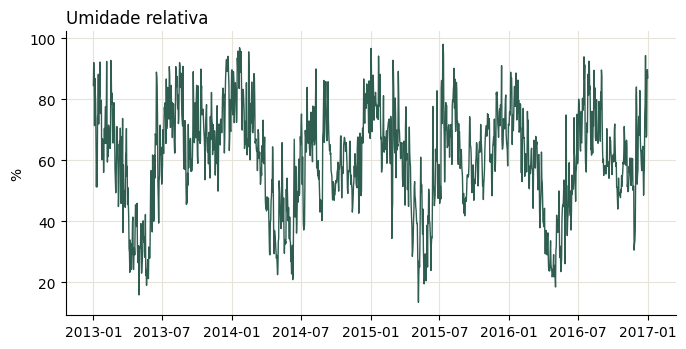

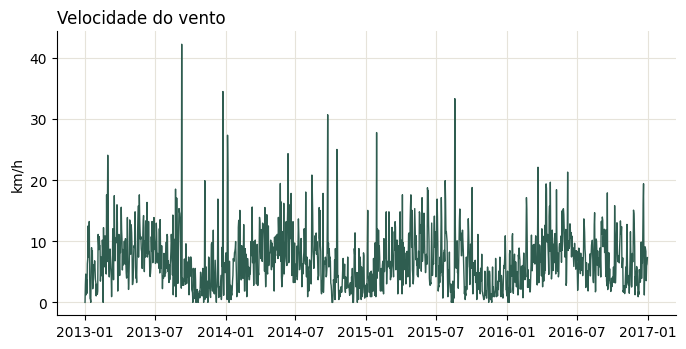

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["meantemp"], color=COR, lw=1)
ax.plot(df.index, df["meantemp"].rolling(30, center=True).mean(),
        color="#6b6558", ls="--", lw=1.8, label="média móvel 30 dias")
ax.set_title("Temperatura média diária — Delhi (2013–2016)")
ax.set_ylabel("°C")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig("img/serie_alvo.png", dpi=150)
plt.show()

for col, titulo, unidade in [("humidity", "Umidade relativa", "%"),
                             ("wind_speed", "Velocidade do vento", "km/h")]:
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.plot(df.index, df[col], color=COR, lw=1)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)
    plt.tight_layout()
    plt.savefig(f"img/{col}.png", dpi=150)
    plt.show()

In [8]:
print(df["meantemp"].describe().round(2).to_string())

print("\nMédia anual:")
print(df["meantemp"].groupby(df.index.year).mean().round(2).to_string())

print("\nMédia mensal:")
print(df["meantemp"].groupby(df.index.month).mean().round(1).to_string())

print("\nCorrelação com meantemp:")
print(df.corr()["meantemp"].round(2).to_string())

count    1461.00
mean       25.51
std         7.34
min         6.00
25%        18.86
50%        27.71
75%        31.31
max        38.71

Média anual:
date
2013    24.79
2014    25.01
2015    25.11
2016    27.10

Média mensal:
date
1     13.3
2     17.6
3     22.9
4     29.4
5     33.3
6     33.7
7     31.0
8     30.6
9     30.4
10    27.1
11    20.7
12    15.7

Correlação com meantemp:
meantemp      1.00
humidity     -0.57
wind_speed    0.31


**Interpretação:**
- A temperatura tem média de 25,5 °C e varia de 6 °C (jan/2013) a 38,7 °C (mai/2013).
- O ciclo anual domina: mínimo em janeiro (≈ 13 °C), máximo em maio–junho (≈ 33–34 °C) e um patamar de ~30–31 °C de julho a setembro (monção).
- A média anual fica em ~25 °C de 2013 a 2015 e sobe para 27,1 °C em 2016.
- **Umidade** tem correlação de −0,57 com a temperatura: é mínima em abril–junho e máxima no inverno e na monção.
- **Vento** tem correlação de +0,31: é mais forte no verão, com picos isolados de até 42 km/h.

## Decomposição STL

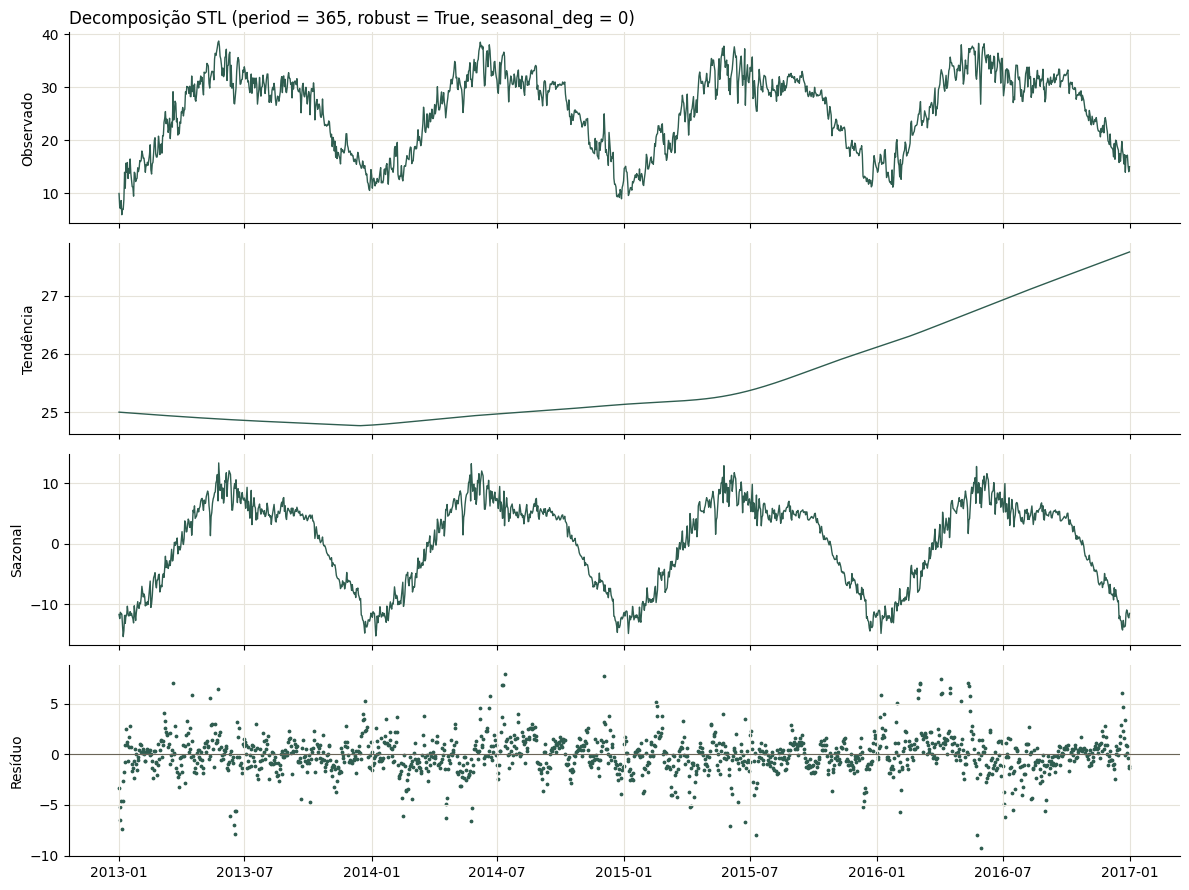

In [9]:
# Série diária com ciclo anual: 365 observações por ciclo
m = 365

# seasonal_deg=0: com só 4 ciclos, cada subsérie sazonal tem 4 pontos; o ajuste
# localmente constante evita que a sazonal absorva o ruído do 1º e do último ano
stl = STL(
    df["meantemp"],
    period=m,
    robust=True,
    seasonal_deg=0
).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
componentes = [("Observado", stl.observed), ("Tendência", stl.trend),
               ("Sazonal", stl.seasonal)]
for ax, (nome, serie) in zip(axes, componentes):
    ax.plot(serie.index, serie, color=COR, lw=1)
    ax.set_ylabel(nome)
axes[3].scatter(stl.resid.index, stl.resid, s=3, color=COR)
axes[3].axhline(0, color="#6b6558", lw=0.8)
axes[3].set_ylabel("Resíduo")
axes[0].set_title("Decomposição STL (period = 365, robust = True, seasonal_deg = 0)")
plt.tight_layout()
plt.savefig("img/stl.png", dpi=150)
plt.show()

### Tendência

In [10]:
trend = stl.trend

# Nível da tendência no início de cada trimestre
print(trend.resample("QS").first().round(2).to_string())

# Mudanças de direção: pontos onde a inclinação troca de sinal
inclinacao = np.sign(trend.diff())
mudancas = inclinacao[inclinacao.diff().fillna(0) != 0]
print("\nMudanças de direção:", [d.strftime("%d/%m/%Y") for d in mudancas.index])
print(f"Mínimo da tendência: {trend.min():.2f} °C em {trend.idxmin():%d/%m/%Y}")

# Inclinação média (°C por mês) em cada fase
fases = {
    "jan/2013 – dez/2013": ("2013-01-01", "2013-12-15"),
    "dez/2013 – mai/2015": ("2013-12-15", "2015-05-31"),
    "jun/2015 – dez/2016": ("2015-06-01", "2016-12-31"),
}
print()
for nome, (ini, fim) in fases.items():
    delta = trend[fim] - trend[ini]
    meses = (pd.Timestamp(fim) - pd.Timestamp(ini)).days / 30.44
    print(f"{nome}: {trend[ini]:.2f} → {trend[fim]:.2f} °C "
          f"(Δ = {delta:+.2f} °C, {delta / meses:+.3f} °C/mês)")

date
2013-01-01    25.00
2013-04-01    24.93
2013-07-01    24.86
2013-10-01    24.81
2014-01-01    24.78
2014-04-01    24.88
2014-07-01    24.97
2014-10-01    25.05
2015-01-01    25.14
2015-04-01    25.20
2015-07-01    25.37
2015-10-01    25.74
2016-01-01    26.11
2016-04-01    26.50
2016-07-01    26.93
2016-10-01    27.34
Freq: QS-JAN

Mudanças de direção: ['16/12/2013']
Mínimo da tendência: 24.77 °C em 15/12/2013

jan/2013 – dez/2013: 25.00 → 24.77 °C (Δ = -0.23 °C, -0.020 °C/mês)
dez/2013 – mai/2015: 24.77 → 25.29 °C (Δ = +0.52 °C, +0.030 °C/mês)
jun/2015 – dez/2016: 25.29 → 27.75 °C (Δ = +2.46 °C, +0.129 °C/mês)


**Interpretação da tendência:**
- **Queda leve (jan/2013 – dez/2013):** a tendência cai de 25,0 para 24,8 °C (−0,2 °C). Na prática, é quase estável.
- **Mudança de direção (dez/2013):** o mínimo da tendência (24,77 °C) ocorre em 15/12/2013, e a partir daí ela passa a subir.
- **Crescimento lento, quase estável (dez/2013 – mai/2015):** +0,5 °C em ~17 meses.
- **Aceleração (meados de 2015):** a inclinação aumenta, mas sem troca de sinal.
- **Crescimento forte e contínuo (jun/2015 – dez/2016):** de 25,3 para 27,7 °C (+2,5 °C em ~19 meses), acompanhando o ano excepcionalmente quente de 2016.
- A variação total (~3 °C) é pequena perto da amplitude sazonal (~22 °C). Com só 4 ciclos, não dá para separar tendência de longo prazo de variação entre anos.

### Sazonalidade e Resíduo

In [11]:
seasonal = stl.seasonal
residual = stl.resid

# Perfil médio da sazonal por mês
print("Componente sazonal média por mês (°C):")
print(seasonal.groupby(seasonal.index.month).mean().round(1).to_string())

# Suavizada em 30 dias para tirar o ruído diário que sobra na sazonal
s30 = seasonal.rolling(30, center=True).mean()
print(f"\nSazonal suavizada: mín {s30.min():.1f} °C ({s30.idxmin():%d/%m/%Y}), "
      f"máx {s30.max():.1f} °C ({s30.idxmax():%d/%m/%Y}), "
      f"amplitude {s30.max() - s30.min():.1f} °C")
print(f"Sazonal diária: mín {seasonal.min():.1f} °C, máx {seasonal.max():.1f} °C")

print(f"\nResíduo: média {residual.mean():.3f}, desvio-padrão {residual.std():.2f} °C")
print("Desvio-padrão por ano:", residual.groupby(residual.index.year).std().round(2).to_dict())
print(f"Mín {residual.min():.1f} °C, máx {residual.max():.1f} °C")
n_ext = (residual.abs() > 3 * residual.std()).sum()
print(f"Dias com |resíduo| > 3 dp: {n_ext} ({n_ext / len(residual):.1%})")
print(f"ADF p-valor: {adfuller(residual)[1]:.1e} | KPSS estatística: {kpss(residual)[0]:.3f}")

Componente sazonal média por mês (°C):
date
1    -11.8
2     -7.6
3     -2.8
4      3.9
5      7.7
6      8.6
7      5.7
8      5.1
9      4.9
10     1.4
11    -5.1
12   -10.4

Sazonal suavizada: mín -12.6 °C (02/01/2014), máx 9.5 °C (05/06/2013), amplitude 22.0 °C
Sazonal diária: mín -15.4 °C, máx 13.3 °C

Resíduo: média -0.042, desvio-padrão 1.90 °C
Desvio-padrão por ano: {2013: 1.83, 2014: 1.89, 2015: 1.68, 2016: 2.13}
Mín -9.2 °C, máx 7.9 °C
Dias com |resíduo| > 3 dp: 36 (2.5%)
ADF p-valor: 9.9e-19 | KPSS estatística: 0.066


C:\Users\karinamartins-ieg\AppData\Local\Temp\ipykernel_14316\2381602198.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(f"ADF p-valor: {adfuller(residual)[1]:.1e} | KPSS estatística: {kpss(residual)[0]:.3f}")


**Interpretação da sazonalidade:**
- O ciclo é anual, grande e regular. Suavizada, a sazonal vai de ≈ −12,6 °C (início de janeiro) a ≈ +9,5 °C (início de junho), uma amplitude de ~22 °C. Nos valores diários os extremos chegam a −15,4 e +13,3 °C porque parte do ruído fica na sazonal (há poucos ciclos para suavizá-la).
- O formato é assimétrico e se repete nos quatro anos: subida gradual de janeiro a maio, pico antes da monção, patamar de julho a setembro (≈ +5 °C) e queda rápida de outubro a dezembro.

**Interpretação do resíduo:**
- Centrado em zero, com desvio-padrão de ~1,9 °C e variância parecida entre os anos (1,7 a 2,1 °C).
- Sem padrão sazonal visível. ADF e KPSS concordam que é estacionário.
- Há picos isolados de até −9 e +8 °C (frentes frias, ondas de calor, chuva forte). Cerca de 36 dias (2,5%) passam de 3 desvios-padrão.

### Força da Tendência e da Sazonalidade

$F_S = \max\left(0,\ 1 - \dfrac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right) \qquad F_T = \max\left(0,\ 1 - \dfrac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$

In [12]:
trend = stl.trend
seasonal = stl.seasonal
residual = stl.resid

forca_sazonalidade = max(
    0,
    1 - (
        np.var(residual) /
        np.var(seasonal + residual)
    )
)

forca_tendencia = max(
    0,
    1 - (
        np.var(residual) /
        np.var(trend + residual)
    )
)

# Resultados
print(f'Força da Sazonalidade: {forca_sazonalidade:.4f}')
print(f'Força da Tendência: {forca_tendencia:.4f}')

Força da Sazonalidade: 0.9319
Força da Tendência: 0.1915


**Interpretação:**
- A **sazonalidade anual é muito forte** (F_S ≈ 0,93): quase toda a variação da temperatura é explicada pelo ciclo verão/inverno, que deve ser modelado explicitamente.
- A **tendência é fraca** (F_T ≈ 0,19): explica pouco além do resíduo.
- Obs.: com `period=12` o STL procuraria um ciclo de 12 dias, que não existe, e o ciclo anual seria absorvido pela tendência, invertendo as conclusões.

## Testes de Estacionariedade

In [13]:
# Funções
def test_adf(x):
    res = adfuller(x)

    results = {
        'ADF Statistic': res[0],
        'p-value': res[1],
        'Critical Values 1/5/10%': res[4],
    }

    print('ADF')

    for k, v in results.items():
        print(f' {k}: {v}')

def test_kpss(x):
    res = kpss(x)

    results = {
        'KPSS Statistic': res[0],
        'p-value': res[1],
        'Critical Values 10/5/2.5/1%': res[3],
    }

    print('KPSS')

    for k, v in results.items():
        print(f' {k}: {v}')

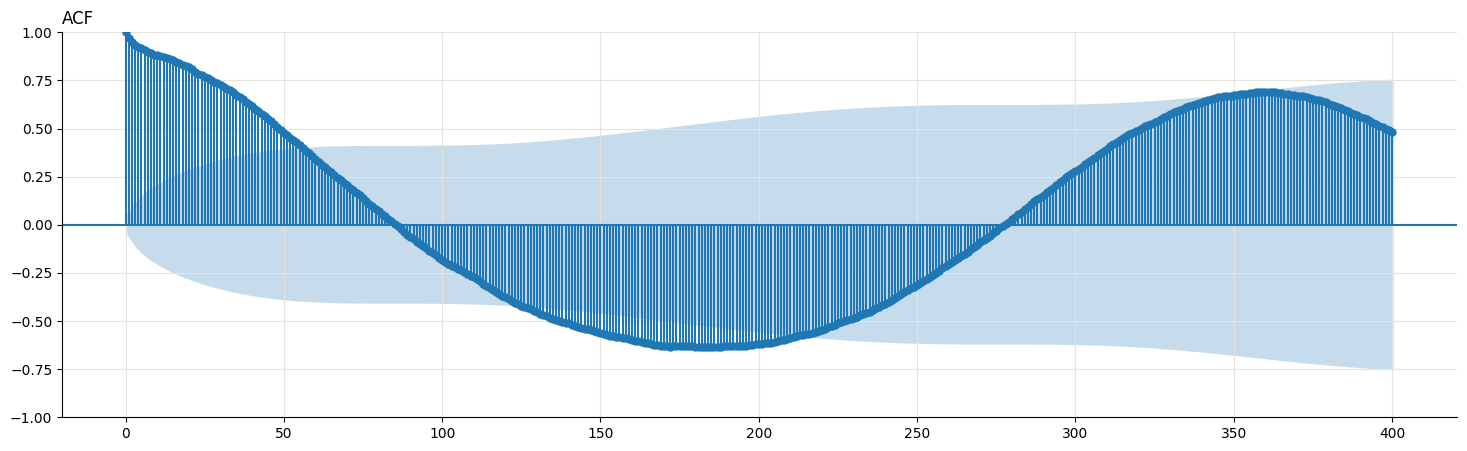

ADF
 ADF Statistic: -2.155565227446429
 p-value: 0.22276593986733573
 Critical Values 1/5/10%: {'1%': np.float64(-3.4348678719530934), '5%': np.float64(-2.863535337271721), '10%': np.float64(-2.5678323015457787)}

KPSS
 KPSS Statistic: 0.19176382197969408
 p-value: 0.1
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\karinamartins-ieg\AppData\Local\Temp\ipykernel_14316\2300485443.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(x)


In [14]:
# 400 lags para enxergar o ciclo anual (lag 365)
fig, ax = plt.subplots(figsize=(18,5))
plot_acf(df["meantemp"], lags=400, ax=ax)
ax.set_title('ACF')
plt.show()

test_adf(df["meantemp"])
print()
test_kpss(df["meantemp"])

**Interpretação:**
- **ADF** não rejeita H0 (p > 0.05) → indicaria raiz unitária (não estacionária).
- **KPSS** não rejeita H0 (estatística < valor crítico de 10%) → indicaria estacionariedade.
- Os testes **discordam**. A ACF mostra uma onda senoidal (negativa perto do lag 182, positiva perto do lag 365): a persistência vem de uma **sazonalidade anual determinística forte**, e não necessariamente de uma raiz unitária. Esse tipo de padrão reduz o poder do ADF.

## Diferenciação

ADF
 ADF Statistic: -16.520440592332665
 p-value: 2.0666135559466146e-29
 Critical Values 1/5/10%: {'1%': np.float64(-3.4348678719530934), '5%': np.float64(-2.863535337271721), '10%': np.float64(-2.5678323015457787)}

KPSS
 KPSS Statistic: 0.14703290223179305
 p-value: 0.1
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\karinamartins-ieg\AppData\Local\Temp\ipykernel_14316\2300485443.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(x)


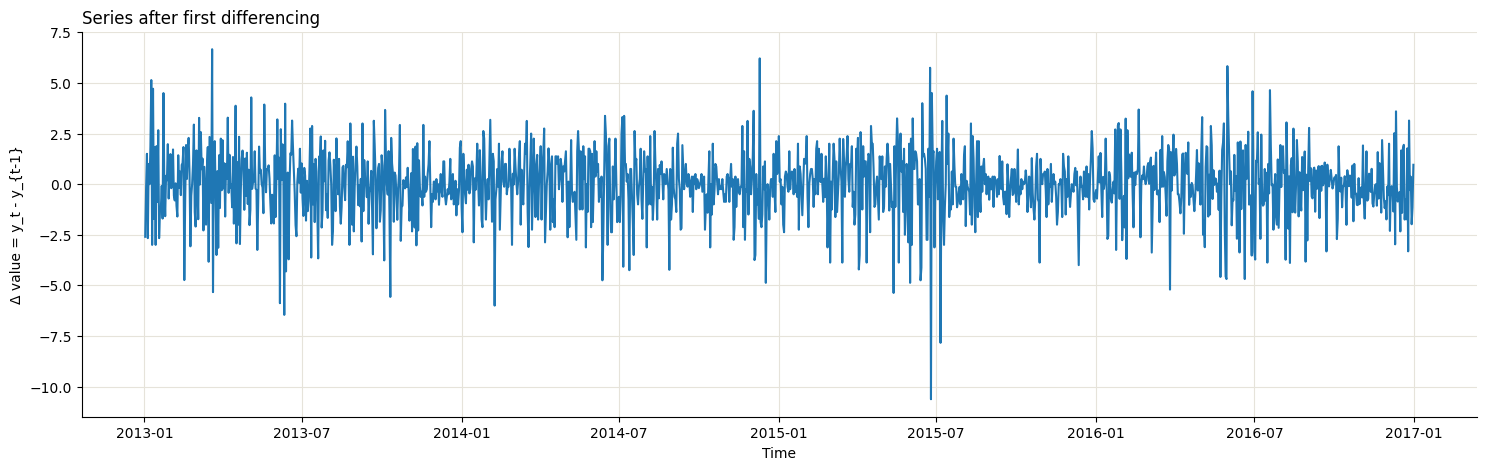

In [15]:
diff = df["meantemp"].diff(1).dropna()

adf_diff = test_adf(diff)
print()
kpss_diff = test_kpss(diff)

plt.figure(figsize=(18,5))
plt.plot(diff.index, diff.values)

plt.title('Series after first differencing')
plt.xlabel('Time')
plt.ylabel('Δ value = y_t - y_{t-1}')

plt.show()

**Interpretação:**
- Após a 1ª diferença, o ADF rejeita H0 com folga e o KPSS não rejeita → a série diferenciada é **estacionária** (d = 1).
- A diferença de 1ª ordem **não remove a sazonalidade anual**, apenas a atenua. A diferenciação sazonal (lag 365) custaria 1 dos 4 anos de dados, então não compensa.
- Alternativas para tratar a sazonalidade: termos de Fourier como exógenas (ARIMAX), Prophet, ou modelar o resíduo do STL(365).

## Análise de ACF e PACF 

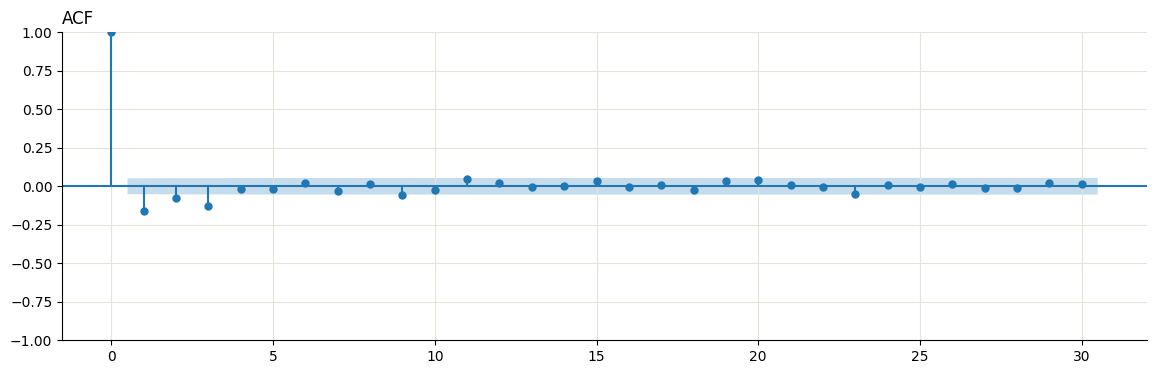

In [16]:
fig, ax = plt.subplots(figsize=(14,4))
plot_acf(diff, lags=30, ax=ax)
ax.set_title('ACF')
plt.show()

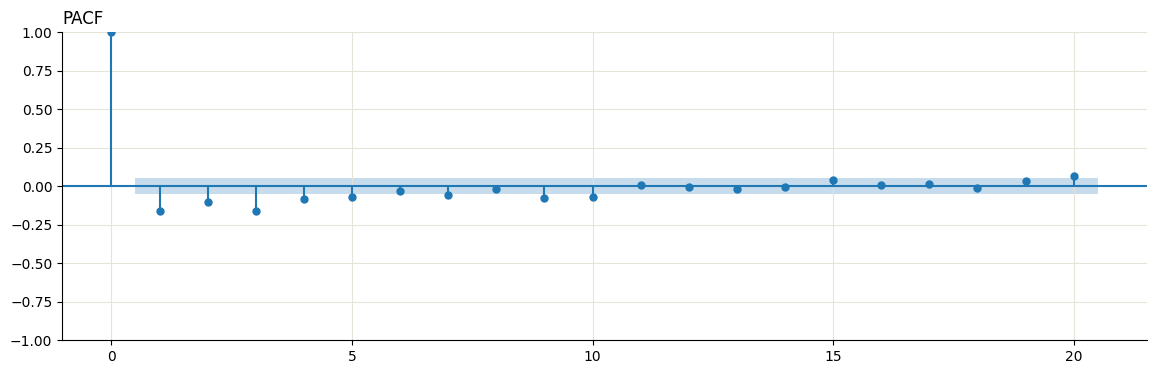

In [17]:
MAX_LAG = 20

fig, ax = plt.subplots(figsize=(14,4))
plot_pacf(diff, lags=MAX_LAG, ax=ax, title="PACF")
plt.show()

**Interpretação** (limite de significância ≈ ±1.96/√n ≈ ±0.05):
- **ACF**: negativa e significativa nos lags 1 a 3 (≈ −0.16, −0.08, −0.13) e depois próxima de zero → sugere componente **MA** com q entre 1 e 3.
- **PACF**: negativa e decaindo aos poucos ao longo dos primeiros lags → também é característico de processo **MA**.
- Modelos candidatos: **ARIMA(0,1,1)**, **ARIMA(0,1,3)**, **ARIMA(1,1,1)** e **ARIMA(3,1,0)**, comparados por AIC/BIC e validados com o teste de Ljung-Box nos resíduos.